In [1]:
import os
from langchain import hub
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, ToolMessage, BaseMessage, HumanMessage, AIMessage, FunctionMessage
from langchain_core.documents import Document
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_community.document_loaders import DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import END, StateGraph, MessagesState
from langgraph.graph.state import CompiledStateGraph

In [2]:
# Setup LangSmith
envs = {
    "LANGSMITH_TRACING": "true",
    "LANGSMITH_ENDPOINT": "https://api.smith.langchain.com",
    "LANGSMITH_API_KEY": "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",
    "LANGSMITH_PROJECT": "ll-tim",
}
for k, v in envs.items():
    os.environ[k] = v

In [3]:
# Model parameters
DOCS_DIR = "../docs"
PERSIST_DIR = "../storage"
LLM_MODEL = "llama3.2:1b"
# LLM_MODEL = "llama3-groq-tool-use"
EMBEDDING_MODEL = "BAAI/bge-base-en-v1.5"

In [4]:
# Load LLM + embedding model
llm = ChatOllama(
    model=LLM_MODEL,
    temperature=0
)
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

In [5]:
## VECTOR STORE

# Check if the vector store already exists
if os.path.exists(PERSIST_DIR):
    print("Loading existing vector store...")
    vector_store = Chroma(
        persist_directory=PERSIST_DIR, embedding_function=embeddings
    )
else:
    print("Creating new vector store...")
    # Process documents for RAG
    loader = DirectoryLoader(DOCS_DIR)
    docs = loader.load()
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000, chunk_overlap=200
    )
    all_splits = text_splitter.split_documents(docs)

    # Create a new vector store and add documents
    vector_store = Chroma.from_documents(
        documents=all_splits,
        embedding=embeddings,
        persist_directory=PERSIST_DIR,
    )
    print("Vector store created and documents indexed.")
print("Vector store loaded")
retriever = vector_store.as_retriever(k=1) # can be invoked later

Loading existing vector store...
Vector store loaded


In [6]:
graph_builder = StateGraph(MessagesState)

In [7]:
def retrieve(state: MessagesState):
    """Retrieve information related to a query."""
    retrieved_docs = retriever.invoke(state["messages"][-1].content)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\n" f"Content: {doc.page_content}")
        for doc in retrieved_docs
    )
    return {"messages": [
        FunctionMessage(serialized, name="retrieve")
    ]}

In [8]:
def generate(state: MessagesState):
    """Generate answer."""
    retrieved_messages = []
    for message in reversed(state["messages"]):
        if message.type == "function":
            retrieved_messages.append(message)
        else:
            break
    retrieved_messages = retrieved_messages[::-1]

    # Format into prompt
    docs_content = "\n\n".join(doc.content for doc in retrieved_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system", "ai")
    ]
    print(conversation_messages)
    prompt = [SystemMessage(system_message_content)] + conversation_messages

    # Run
    response = llm.invoke(prompt)
    return {"messages": [response]}

In [9]:
graph_builder.add_node(retrieve)
graph_builder.add_node(generate)

graph_builder.set_entry_point("retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

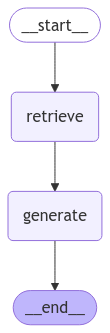

In [10]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
input_message = "Hello"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hello
=============================== Function Message ===============================
Name: retrieve

Source: {'source': 'docs/Example Application.docx'}
Content: Paper Presentations



Functional Circuits:

Quantum Theory in Practice, 2025, Poster, First Author (submission)

Quantum Physics and Logic, 2025, Poster, First Author (submission)

Reduction to a Subsystem Always Internalises:

Quantum TUT Workshop, 2023, Workshop, First Author

Quantum Physics and Logic, 2023, Poster, First Author

Entanglement-efficient bipartite-distributed quantum computing:

Japan-French Quantum Information Workshop, 2023, Workshop, Co-author

Quantum Physics and Logic, 2023, Poster, Co-author

Japan-Singapore Joint Seminar, 2023, Poster, Co-author

International Symposium on Trans-Scale Quantum Science, 2022, Poster, Co-author

Entanglement-assisted LOCC implementation of bipartite non-local unitary operations:

Quantum 

In [12]:
input_message = "Who is Tim Forrer?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Who is Tim Forrer?
=============================== Function Message ===============================
Name: retrieve

Source: {'source': 'docs/FORRER-CV_1.docx'}
Content: CV

Tim Forrer

tim.d.forrer@gmail.com | +81 (0) 80 9405 7118

SUMMARY

Driven and adaptable PhD student with a history of high achievement and a strong team-oriented approach. Native English speaker with proficient Japanese and Mandarin. Long-standing interest in markets and global economies, currently being pursued through additional graduate-level studies of economics and public policy. Eager to take on opportunities to learn and thrive as a reporter.

EDUCATION

Physics PhD - University of Tokyo, Japan	Oct 2022 - Present

Researching applications of abstract math methods to aid understanding of quantum computing.

Delivered invited talks and presentations on research findings.

Strengthened ability to tailor communication for diverse a

In [13]:
input_message = "Where did he go to university?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Where did he go to university?
=============================== Function Message ===============================
Name: retrieve

Source: {'source': 'docs/FORRER-CV_0.docx'}
Content: Physics Research Student - University of Tokyo, Japan	Oct 2021 - Sept 2022

Worked with industry on an open source implementation of joint theoretical research.

Gained greater proficiency with software development as part of a team - particularly regarding best practices with Git, code reviews, and unit testing.

Repository available at: https://github.com/CQCL/pytket-dqc

Natural Sciences MSci (1st Class Honors) - Durham University, UK	Oct 2017 - Jul 2021

AWARDS AND CERTIFICATIONS

Embassy-Recommended MEXT Scholarship 	Oct 2021 - Present

Awarded by the Ministry of Education, Culture, Sports, Science and Technology for Japan on the recommendation of the Japanese Embassy in the UK.

Natural Sciences Award for Outstanding Achi

In [14]:
input_message = "What's his email address?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What's his email address?
=============================== Function Message ===============================
Name: retrieve

Source: {'source': 'docs/Example Application.docx'}
Content: Paper Presentations



Functional Circuits:

Quantum Theory in Practice, 2025, Poster, First Author (submission)

Quantum Physics and Logic, 2025, Poster, First Author (submission)

Reduction to a Subsystem Always Internalises:

Quantum TUT Workshop, 2023, Workshop, First Author

Quantum Physics and Logic, 2023, Poster, First Author

Entanglement-efficient bipartite-distributed quantum computing:

Japan-French Quantum Information Workshop, 2023, Workshop, Co-author

Quantum Physics and Logic, 2023, Poster, Co-author

Japan-Singapore Joint Seminar, 2023, Poster, Co-author

International Symposium on Trans-Scale Quantum Science, 2022, Poster, Co-author

Entanglement-assisted LOCC implementation of bipartite non-local unitary o

In [15]:
input_message = "What papers has he presented?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What papers has he presented?
=============================== Function Message ===============================
Name: retrieve

Source: {'source': 'docs/Example Application.docx'}
Content: Paper Presentations



Functional Circuits:

Quantum Theory in Practice, 2025, Poster, First Author (submission)

Quantum Physics and Logic, 2025, Poster, First Author (submission)

Reduction to a Subsystem Always Internalises:

Quantum TUT Workshop, 2023, Workshop, First Author

Quantum Physics and Logic, 2023, Poster, First Author

Entanglement-efficient bipartite-distributed quantum computing:

Japan-French Quantum Information Workshop, 2023, Workshop, Co-author

Quantum Physics and Logic, 2023, Poster, Co-author

Japan-Singapore Joint Seminar, 2023, Poster, Co-author

International Symposium on Trans-Scale Quantum Science, 2022, Poster, Co-author

Entanglement-assisted LOCC implementation of bipartite non-local unita